# Data processing: UMAP EDA 

| Dataset | Matrix | Feature pick for UMAP | Color after the fit |
|---|---|---|---|
| TARGET RNA-seq | log2(TMM-CPM+1), Batch counts only | top 5% HVGs | `Dx` from `TARGET_meta.txt` |
| TARGET methylation | beta, `.Ave_Beta` columns only | top 5% variance, 450K and EPIC **separate**; also **common CpGs** UMAP | disease from TARGET barcode |
| PCGP RNA-seq | log2(TMM-CPM+1), count file only | its own top 5% HVGs | / |
| COMET RMS | beta, `.Ave_Beta` only | top 5% variance (all types); later cell: **patient tumor only** | sample type / unlabeled |

**MedGemma (later, not the UMAP gene/CpG lists):**

- RNA-seq prompt: log2(TMM-CPM+1), **~200 HVGs chosen on the training patients only**
- Methylation prompt: **F-test (or limma) on the training arrays**, ~20 CpGs per class, M-value for the test, beta in the text


In [2]:
from pathlib import Path
import csv
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap.umap_ as umap
from scipy import stats

plt.rcParams["figure.dpi"] = 130

/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys

REPO_ROOT = Path("/Users/rita/medgemma-fl")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
DATA_ROOT = REPO_ROOT / "rawdata"
OUT_ROOT = REPO_ROOT / "outputs" / "data_processing"

RNASEQ_DIR = DATA_ROOT / "RNAseq"
META_PATH = RNASEQ_DIR / "TARGET_meta.txt"
PCGP_DIR = DATA_ROOT / "PCGP"
METH_DIR = DATA_ROOT / "methyl"
COMET_DIR = DATA_ROOT / "COMET_RMS"

RNA_OUT = OUT_ROOT / "rnaseq"
METH_OUT = OUT_ROOT / "methyl"
PCGP_OUT = OUT_ROOT / "pcgp"
COMET_OUT = OUT_ROOT / "comet_rms"
for d in (RNA_OUT, METH_OUT, PCGP_OUT, COMET_OUT):
    d.mkdir(parents=True, exist_ok=True)

MIN_COUNT = 10
MIN_SAMPLES = 10
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
RANDOM_STATE = 42
METH_CHUNK_ROWS = 1500
METH_MIN_PROBE_COVERAGE = 0.95
N_PROMPT_HVG = 200
N_CPG_PER_CLASS = 20

for name, path in [
    ("RNAseq", RNASEQ_DIR), ("meta", META_PATH), ("PCGP", PCGP_DIR),
    ("methyl", METH_DIR), ("COMET_RMS", COMET_DIR),
]:
    ok = path.is_dir() if name != "meta" else path.is_file()
    print(f"{name:10s} {'OK' if ok else 'MISSING':8s} {path}")
    if not ok:
        raise FileNotFoundError(path)

RNAseq     OK       /Users/rita/medgemma-fl/rawdata/RNAseq
meta       OK       /Users/rita/medgemma-fl/rawdata/RNAseq/TARGET_meta.txt
PCGP       OK       /Users/rita/medgemma-fl/rawdata/PCGP
methyl     OK       /Users/rita/medgemma-fl/rawdata/methyl
COMET_RMS  OK       /Users/rita/medgemma-fl/rawdata/COMET_RMS


### Helpers


In [4]:
def tmm_norm_factors(counts, log_ratio_trim=0.3, sum_trim=0.05):
    library_sizes = np.maximum(counts.sum(axis=0), 1.0)
    upper_quartiles = np.percentile(counts, 75, axis=0)
    ref_idx = int(np.argmin(np.abs(upper_quartiles - np.mean(upper_quartiles))))
    ref_counts = counts[:, ref_idx]
    ref_lib = library_sizes[ref_idx]
    factors = np.ones(counts.shape[1], dtype=np.float64)
    for sample_idx in range(counts.shape[1]):
        if sample_idx == ref_idx:
            continue
        obs = counts[:, sample_idx]
        obs_lib = library_sizes[sample_idx]
        keep = (obs > 0) & (ref_counts > 0)
        if int(keep.sum()) < 50:
            continue
        obs_k, ref_k = obs[keep], ref_counts[keep]
        log_r = np.log2((obs_k / obs_lib) / (ref_k / ref_lib))
        abs_e = 0.5 * np.log2((obs_k / obs_lib) * (ref_k / ref_lib))
        var = (obs_lib - obs_k) / (obs_lib * obs_k) + (ref_lib - ref_k) / (ref_lib * ref_k)
        finite = np.isfinite(log_r) & np.isfinite(abs_e) & np.isfinite(var) & (var > 0)
        log_r, abs_e, var = log_r[finite], abs_e[finite], var[finite]
        if log_r.size < 50:
            continue
        n = log_r.size
        lo_m, hi_m = int(np.floor(n * log_ratio_trim)), int(np.ceil(n * (1 - log_ratio_trim)))
        lo_a, hi_a = int(np.floor(n * sum_trim)), int(np.ceil(n * (1 - sum_trim)))
        keep_m = np.zeros(n, dtype=bool)
        keep_a = np.zeros(n, dtype=bool)
        keep_m[np.argsort(log_r)[lo_m:hi_m]] = True
        keep_a[np.argsort(abs_e)[lo_a:hi_a]] = True
        selected = keep_m & keep_a
        if not np.any(selected):
            continue
        weights = 1.0 / var[selected]
        factors[sample_idx] = 2.0 ** (np.sum(weights * log_r[selected]) / np.sum(weights))
    return factors / np.exp(np.mean(np.log(np.maximum(factors, 1e-8))))


def log2_tmm_cpm(counts):
    factors = tmm_norm_factors(counts)
    effective_lib = np.maximum(counts.sum(axis=0) * factors, 1.0)
    return np.log2(counts / effective_lib * 1e6 + 1.0), factors


def protein_coding_expressed(counts, bio_types, min_count=MIN_COUNT, min_samples=MIN_SAMPLES):
    bio = np.asarray(bio_types)
    expressed = (counts >= min_count).sum(axis=1) >= min(min_samples, counts.shape[1])
    return (bio == "protein_coding") & expressed


def top_variance_indices(matrix, fraction=0.05, mask=None):
    # matrix is features x samples; rank by variance across samples
    if mask is None:
        mask = np.ones(matrix.shape[0], dtype=bool)
    var = np.var(matrix[mask], axis=1)
    n_keep = max(2, int(math.ceil(int(mask.sum()) * fraction)))
    local = np.argsort(var)[::-1][:n_keep]
    return np.flatnonzero(mask)[local], var


def fit_umap(feature_by_sample, random_state=RANDOM_STATE):
    X = np.asarray(feature_by_sample, dtype=np.float64).T
    print(f"UMAP input: {X.shape[0]} samples x {X.shape[1]} features")
    reducer = umap.UMAP(
        n_neighbors=min(UMAP_N_NEIGHBORS, X.shape[0] - 1),
        min_dist=UMAP_MIN_DIST,
        n_components=2,
        metric="euclidean",
        random_state=random_state,
    )
    return reducer.fit_transform(X)


def scatter_by_label(ax, xy, labels, title, unknown=("UNKNOWN", "NA", "", None)):
    labels = pd.Series(labels).fillna("UNKNOWN").astype(str)
    palette = plt.cm.tab20(np.linspace(0, 1, max(labels.nunique(), 1)))
    codes = sorted(c for c in labels.unique() if c not in unknown)
    for lab in labels.unique():
        idx = labels.to_numpy() == lab
        if lab in unknown:
            ax.scatter(xy[idx, 0], xy[idx, 1], s=8, c="lightgray", alpha=0.25, label=lab, linewidths=0)
        else:
            color = palette[codes.index(lab) % len(palette)]
            ax.scatter(xy[idx, 0], xy[idx, 1], s=12, color=color, alpha=0.85, label=lab, linewidths=0)
    ax.set(title=title, xlabel="UMAP 1", ylabel="UMAP 2")
    ax.legend(loc="best", fontsize=7, markerscale=1.4, frameon=False)

### RNA-seq — Batch counts only

Use `WU-TARGET-Batch*` **gene_count** files. Skip `AML_B*` (no Dx in meta) and every `*TPM*` file.

Batch files contain 1,147 unique samples. `TARGET_meta.txt` has Dx for 1,095 of them and is missing Dx for 52. Those 52 are **dropped** before TMM / HVG / UMAP. 

In [5]:
COUNT_FILE_RE = re.compile(
    r"^WU-TARGET[-_](?P<source>Batch|AML_B)(?P<number>\d+)-"
    r"(?P<strand>STRANDED|UNSTRANDED)_RSEM_gene_count(?:\..*)?\.txt$",
    re.IGNORECASE,
)


def normalize_sample_id(sample_id):
    return str(sample_id).strip().replace(".", "-")


def load_diagnosis_map(meta_path):
    diagnoses = {}
    with open(meta_path, newline="") as handle:
        reader = csv.DictReader(handle, delimiter="\t")
        for row in reader:
            sid = normalize_sample_id(row["Sample"])
            dx = (row.get("Dx") or "").strip().upper()
            if sid and dx and dx != "NA":
                diagnoses[sid] = dx
    return diagnoses


def read_count_table(path):
    with open(path, newline="") as handle:
        reader = csv.reader(handle, delimiter="\t")
        header = next(reader)
        samples = [normalize_sample_id(x) for x in header[4:]]
        gene_ids, gene_symbols, bio_types, rows = [], [], [], []
        for row in reader:
            gene_ids.append(row[0])
            gene_symbols.append(row[1] or row[0])
            bio_types.append(row[2])
            rows.append([float(v) if v not in ("", "NA") else 0.0 for v in row[4:4 + len(samples)]])
    return gene_ids, gene_symbols, bio_types, samples, np.asarray(rows, dtype=np.float64)


diagnoses = load_diagnosis_map(META_PATH)
batch_files = []
for path in sorted(RNASEQ_DIR.glob("*.txt")):
    match = COUNT_FILE_RE.fullmatch(path.name)
    if match is None:
        continue
    if match.group("source").upper() != "BATCH":
        continue
    strand = match.group("strand").upper()
    number = int(match.group("number"))
    batch_files.append((0 if strand == "STRANDED" else 1, number, strand, path))
batch_files.sort()

print(f"Batch count files: {len(batch_files)} (TPM and AML_B* excluded)")
for _, number, strand, path in batch_files:
    print(f"  Batch{number:02d} {strand:10s} {path.name}")

gene_ids = gene_symbols = bio_types = None
sample_ids, sample_batch, sample_dx, blocks = [], [], [], []
seen = set()
for _, number, strand, path in batch_files:
    g_ids, g_sym, g_bio, sids, counts = read_count_table(path)
    if gene_ids is None:
        gene_ids, gene_symbols, bio_types = g_ids, g_sym, g_bio
    elif g_ids != gene_ids:
        raise ValueError(f"Gene order mismatch in {path.name}")
    keep = []
    for j, sid in enumerate(sids):
        if sid in seen:
            continue
        seen.add(sid)
        keep.append(j)
        sample_ids.append(sid)
        sample_batch.append(number)
        sample_dx.append(diagnoses.get(sid, "UNKNOWN"))
    if keep:
        blocks.append(counts[:, keep])
        print(f"  kept {len(keep):3d} new samples from {path.name}")

rna_counts = np.concatenate(blocks, axis=1)
rna_meta = pd.DataFrame({"sample_id": sample_ids, "batch": sample_batch, "diagnosis": sample_dx})
n_batch = len(rna_meta)
labeled_mask = rna_meta.diagnosis != "UNKNOWN"
n_labeled = int(labeled_mask.sum())
n_unlabeled = n_batch - n_labeled
print(f"Batch count files held {n_batch:,} unique samples")
print(f"  labeled (Dx in TARGET_meta.txt): {n_labeled:,}")
print(f"  dropped (Dx missing / UNKNOWN):  {n_unlabeled:,}")
print(rna_meta.diagnosis.value_counts().to_string())

rna_counts = rna_counts[:, labeled_mask.to_numpy()]
rna_meta = rna_meta.loc[labeled_mask].reset_index(drop=True)
print(f"matrix used for TMM / HVG / UMAP: {rna_counts.shape[0]:,} genes x {rna_counts.shape[1]:,} labeled samples")

Batch count files: 12 (TPM and AML_B* excluded)
  Batch01 STRANDED   WU-TARGET-Batch01-STRANDED_RSEM_gene_count.2021-08-03_08-38-51.txt
  Batch02 STRANDED   WU-TARGET-Batch02-STRANDED_RSEM_gene_count.2021-08-03_21-30-36.txt
  Batch03 STRANDED   WU-TARGET-Batch03-STRANDED_RSEM_gene_count.2021-08-04_05-20-35.txt
  Batch04 STRANDED   WU-TARGET-Batch04-STRANDED_RSEM_gene_count.2021-08-04_01-44-47.txt
  Batch05 STRANDED   WU-TARGET-Batch05-STRANDED_RSEM_gene_count.2021-08-04_01-38-51.txt
  Batch06 STRANDED   WU-TARGET-Batch06-STRANDED_RSEM_gene_count.2021-08-06_11-45-47.txt
  Batch07 STRANDED   WU-TARGET-Batch07-STRANDED_RSEM_gene_count.2021-08-04_23-27-24.txt
  Batch08 STRANDED   WU-TARGET-Batch08-STRANDED_RSEM_gene_count.2021-08-04_21-26-02.txt
  Batch09 STRANDED   WU-TARGET-Batch09-STRANDED_RSEM_gene_count.2021-08-04_22-05-45.txt
  Batch01 UNSTRANDED WU-TARGET-Batch01-UNSTRANDED_RSEM_gene_count.2021-08-05_03-51-00.txt
  Batch02 UNSTRANDED WU-TARGET-Batch02-UNSTRANDED_RSEM_gene_count.2021

In [6]:
eligible = protein_coding_expressed(rna_counts, bio_types)
print(f"protein-coding expressed genes: {int(eligible.sum()):,}")

rna_log, rna_tmm = log2_tmm_cpm(rna_counts)
print(f"TMM factors: min={rna_tmm.min():.3f} median={np.median(rna_tmm):.3f} max={rna_tmm.max():.3f}")

rna_top5_idx, rna_var = top_variance_indices(rna_log, 0.05, eligible)
print(f"top 5% HVGs: {len(rna_top5_idx)}")

hvg_table = pd.DataFrame({
    "gene_id": np.asarray(gene_ids)[rna_top5_idx],
    "gene_symbol": np.asarray(gene_symbols)[rna_top5_idx],
    "variance": np.var(rna_log[rna_top5_idx], axis=1),
})
hvg_table.to_csv(RNA_OUT / "rnaseq_batch_top5pct_hvgs.tsv", sep="\t", index=False)
print(hvg_table.head(10).to_string(index=False))

protein-coding expressed genes: 18,957
TMM factors: min=0.167 median=1.042 max=2.185
top 5% HVGs: 948
           gene_id gene_symbol  variance
ENSG00000168542.14      COL3A1 25.057264
ENSG00000164692.17      COL1A2 24.667051
ENSG00000108821.13      COL1A1 24.447901
ENSG00000167244.21        IGF2 24.019173
ENSG00000115414.19         FN1 19.117676
ENSG00000187498.16      COL4A1 17.428278
ENSG00000134871.18      COL4A2 17.379570
ENSG00000182492.16         BGN 16.062503
 ENSG00000244734.4         HBB 15.748319
ENSG00000113140.11       SPARC 15.541879


UMAP input: 1095 samples x 948 features


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


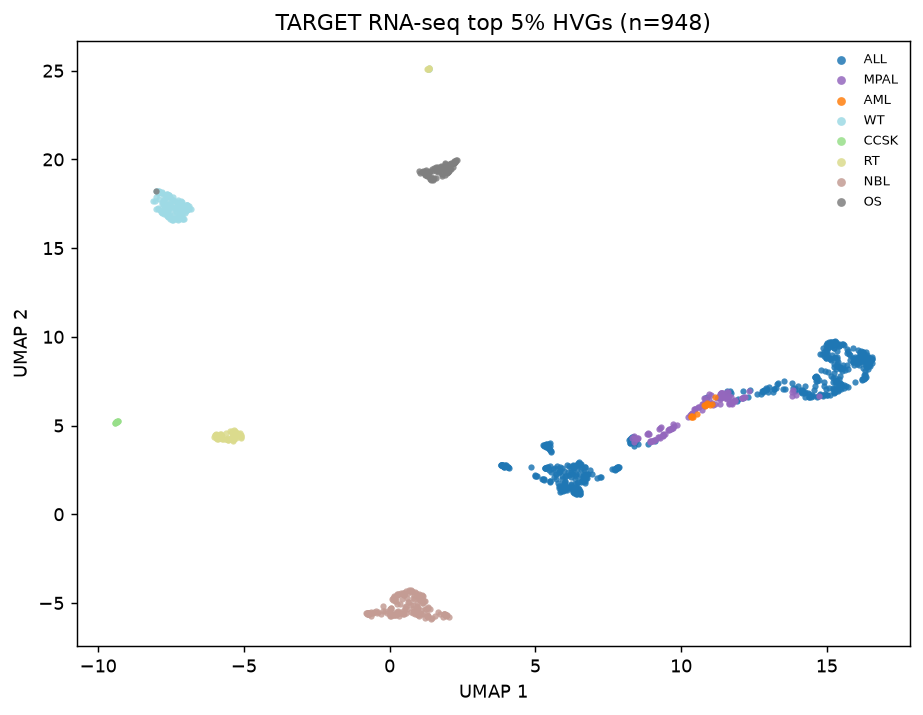

saved /Users/rita/medgemma-fl/outputs/data_processing/rnaseq  (1,095 samples, 948 HVGs)


In [7]:
rna_xy = fit_umap(rna_log[rna_top5_idx])
rna_coords = rna_meta.copy()
rna_coords["UMAP1"] = rna_xy[:, 0]
rna_coords["UMAP2"] = rna_xy[:, 1]
rna_coords.to_csv(RNA_OUT / "rnaseq_batch_top5pct_umap.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(7.2, 5.6))
scatter_by_label(
    ax,
    rna_xy,
    rna_meta.diagnosis,
    f"TARGET RNA-seq top 5% HVGs (n={len(rna_top5_idx)})",
)
fig.tight_layout()
fig.savefig(RNA_OUT / "rnaseq_batch_top5_diagnosis.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {RNA_OUT}  ({len(rna_meta):,} samples, {len(rna_top5_idx)} HVGs)")

### DNA methylation — UMAP uses variance
- Read **only** `*.Ave_Beta` columns. `*.Detection.Pval` is QC, not a sample.
- 450K and EPIC stay in **separate** embeddings (platform is almost perfectly tied to disease).
- Color after the fit from the TARGET barcode, not the file name. The EPIC `ALL-P3` file mixes ALL / MPAL / AML / normal barcodes; the RT file is only RT.
- **Normal / remission arrays are dropped** before variance ranking and UMAP (same idea as dropping unlabeled RNA-seq samples).
- A later cell also takes **CpGs shared by 450K and EPIC**, ranks variance on the pooled tumor arrays, and draws one UMAP (still colored after the fit).


In [8]:
TARGET_DISEASE = {
    "00": "Normal/other", "10": "ALL", "15": "MPAL", "20": "AML", "21": "AML",
    "30": "NBL", "40": "OS", "50": "WT", "51": "CCSK", "52": "RT",
}
NORMAL_STYPES = {"10", "11", "14", "15", "17"}
BARCODE_RE = re.compile(r"TARGET-(\d\d)-([A-Za-z0-9]+)-(\d\d)")


def parse_target_barcode(barcode):
    match = BARCODE_RE.match(str(barcode))
    if match is None:
        return {"proj": None, "patient": None, "stype": None, "disease": "UNKNOWN", "is_normal": False}
    stype = match.group(3)
    return {
        "proj": match.group(1),
        "patient": match.group(2),
        "stype": stype,
        "disease": TARGET_DISEASE.get(match.group(1), f"TARGET-{match.group(1)}"),
        "is_normal": stype in NORMAL_STYPES,
    }


def inspect_beta_file(path):
    name = path.name
    platform_match = re.search(r"_(450K|EPIC|27K)_beta\.txt$", name, flags=re.I)
    if platform_match is None:
        return None
    with open(path, encoding="utf-8-sig") as handle:
        header = handle.readline().rstrip("\n").split("\t")
    beta_cols = [c for c in header[1:] if c.endswith(".Ave_Beta")]
    if not beta_cols:
        raise ValueError(f"No .Ave_Beta columns in {name}")
    sample_ids = [c[: -len(".Ave_Beta")] for c in beta_cols]
    project_match = re.search(r"(TARGET-[A-Z0-9-]+?)_+(?:450K|EPIC|27K)_beta\.txt$", name, flags=re.I)
    return {
        "path": path,
        "platform": platform_match.group(1).upper(),
        "file_project": project_match.group(1).upper() if project_match else name,
        "id_col": header[0],
        "beta_cols": beta_cols,
        "sample_ids": sample_ids,
        "n_samples": len(sample_ids),
    }


meth_files = [inspect_beta_file(p) for p in sorted(METH_DIR.glob("*_beta.txt"))]
meth_files = [f for f in meth_files if f is not None]
inv = []
for f in meth_files:
    for sid, col in zip(f["sample_ids"], f["beta_cols"]):
        parsed = parse_target_barcode(sid)
        inv.append({
            "platform": f["platform"], "file_project": f["file_project"],
            "sample_id": sid, "original_column": col, "source_file": f["path"].name,
            **parsed,
        })
meth_inventory = pd.DataFrame(inv)
print("arrays (Ave_Beta only):", len(meth_inventory))
print("\nplatform x disease")
print(pd.crosstab(meth_inventory.platform, meth_inventory.disease).to_string())
print("\nfile_project x disease  (file name is not a clean label)")
print(pd.crosstab(meth_inventory.file_project, meth_inventory.disease).to_string())
print("\nnormal arrays:", int(meth_inventory.is_normal.sum()))
meth_inventory.to_csv(METH_OUT / "methylation_array_manifest.tsv", sep="\t", index=False)

arrays (Ave_Beta only): 989

platform x disease
disease   ALL  AML  CCSK  MPAL  NBL  Normal/other  OS  RT   WT
platform                                                      
450K        0  317    11     0  223            12  86   0  131
EPIC       59   15     0    50    0            17   0  68    0

file_project x disease  (file name is not a clean label)
disease        ALL  AML  CCSK  MPAL  NBL  Normal/other  OS  RT   WT
file_project                                                       
TARGET-ALL-P3   59   15     0    50    0            17   0   0    0
TARGET-AML       0  317     0     0    0             0   0   0    0
TARGET-CCSK      0    0    11     0    0             0   0   0    0
TARGET-NBL       0    0     0     0  223            12   0   0    0
TARGET-OS        0    0     0     0    0             0  86   0    0
TARGET-RT        0    0     0     0    0             0   0  68    0
TARGET-WT        0    0     0     0    0             0   0   0  131

normal arrays: 169


In [9]:
def stream_beta_variance(files, chunk_rows=METH_CHUNK_ROWS, label=None):
    # Variance of each CpG across Ave_Beta columns only. Files may differ in probe order.
    # usecols must be column *names* only — mixing 0 with names raises in pandas.
    platform = label or files[0]["platform"]
    id_sets = []
    for f in files:
        id_col = f["id_col"]
        ids = pd.read_csv(
            f["path"], sep="\t", usecols=[id_col], dtype=str, encoding="utf-8-sig",
        )[id_col].str.strip()
        id_sets.append(pd.Index(ids.to_numpy(), name="cpg_id"))
    common = id_sets[0]
    for ids in id_sets[1:]:
        common = common[common.isin(ids)]
    print(f"{platform}: {len(common):,} shared CpGs across {len(files)} files")

    n_probes = len(common)
    n_samples = sum(f["n_samples"] for f in files)
    observed = np.zeros(n_probes, dtype=np.int32)
    sums = np.zeros(n_probes, dtype=np.float64)
    sums_sq = np.zeros(n_probes, dtype=np.float64)

    for f in files:
        id_col = f["id_col"]
        usecols = [id_col] + f["beta_cols"]
        print(f"  scanning {f['path'].name} ({f['n_samples']} arrays)")
        for chunk in pd.read_csv(
            f["path"], sep="\t", usecols=usecols, chunksize=chunk_rows,
            encoding="utf-8-sig", na_values=["NA", "NaN", "nan", ""], low_memory=False,
        ):
            ids = chunk[id_col].astype(str).str.strip().to_numpy()
            vals = chunk[f["beta_cols"]].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
            bad = np.isfinite(vals) & ((vals < -1e-6) | (vals > 1 + 1e-6))
            if bad.any():
                raise ValueError(f"beta outside [0, 1] in {f['path'].name}")
            positions = common.get_indexer(ids)
            keep = positions >= 0
            if not keep.any():
                continue
            positions, vals = positions[keep], vals[keep]
            finite = np.isfinite(vals)
            cleaned = np.where(finite, vals, 0.0).astype(np.float64)
            observed[positions] += finite.sum(axis=1)
            sums[positions] += cleaned.sum(axis=1)
            sums_sq[positions] += np.square(cleaned).sum(axis=1)

    denom = np.maximum(observed, 1)
    variance = np.maximum(sums_sq / denom - (sums / denom) ** 2, 0.0)
    stats_df = pd.DataFrame({"cpg_id": common.to_numpy(), "beta_variance": variance, "n_observed": observed})
    min_obs = max(4, math.ceil(n_samples * METH_MIN_PROBE_COVERAGE))
    eligible = stats_df.loc[(stats_df.n_observed >= min_obs) & (stats_df.beta_variance > 1e-10)]
    eligible = eligible.sort_values("beta_variance", ascending=False)
    n5 = max(2, math.ceil(len(eligible) * 0.05))
    top5 = eligible.iloc[:n5].copy().reset_index(drop=True)
    print(f"{platform}: {n_samples:,} arrays; eligible {len(eligible):,}; top 5% = {n5:,}")
    return top5, stats_df


def load_selected_beta(files, cpg_ids):
    wanted = set(cpg_ids)
    blocks = []
    for f in files:
        id_col = f["id_col"]
        usecols = [id_col] + f["beta_cols"]
        parts = []
        for chunk in pd.read_csv(
            f["path"], sep="\t", usecols=usecols, chunksize=METH_CHUNK_ROWS,
            encoding="utf-8-sig", na_values=["NA", "NaN", "nan", ""], low_memory=False,
        ):
            ids = chunk[id_col].astype(str).str.strip()
            hit = ids.isin(wanted)
            if hit.any():
                sub = chunk.loc[hit, f["beta_cols"]].apply(pd.to_numeric, errors="coerce")
                sub.index = ids.loc[hit]
                parts.append(sub)
        selected = pd.concat(parts)
        selected = selected.loc[~selected.index.duplicated()]
        selected = selected.reindex(cpg_ids)
        blocks.append(selected.to_numpy(dtype=np.float32))
    beta = np.concatenate(blocks, axis=1)
    medians = np.nanmedian(beta, axis=1)
    missing = ~np.isfinite(beta)
    beta[missing] = medians[np.where(missing)[0]]
    return beta

files on disk:
                                                         arrays  normal
platform source_file                                                   
450K     idat_sample_sheet_TARGET-AML__450k_beta.txt        317     140
         idat_sample_sheet_TARGET-CCSK__450k_beta.txt        11       0
         idat_sample_sheet_TARGET-NBL__450k_beta.txt        235      12
         idat_sample_sheet_TARGET-OS__450k_beta.txt          86       0
         idat_sample_sheet_TARGET-WT__450k_beta.txt         131       0
EPIC     idat_sample_sheet_TARGET-ALL-P3__EPIC_beta.txt     141      17
         idat_sample_sheet_TARGET-RT__EPIC_beta.txt          68       0

Dropping 169 normal/remission arrays before variance + UMAP

450K tumor files: idat_sample_sheet_TARGET-AML__450k_beta.txt (177), idat_sample_sheet_TARGET-CCSK__450k_beta.txt (11), idat_sample_sheet_TARGET-NBL__450k_beta.txt (223), idat_sample_sheet_TARGET-OS__450k_beta.txt (86), idat_sample_sheet_TARGET-WT__450k_beta.txt (131)
450K: 

/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



EPIC tumor files: idat_sample_sheet_TARGET-ALL-P3__EPIC_beta.txt (124), idat_sample_sheet_TARGET-RT__EPIC_beta.txt (68)
EPIC: 865,859 shared CpGs across 2 files
  scanning idat_sample_sheet_TARGET-ALL-P3__EPIC_beta.txt (124 arrays)
  scanning idat_sample_sheet_TARGET-RT__EPIC_beta.txt (68 arrays)
EPIC: 192 arrays; eligible 865,859; top 5% = 43,293
UMAP input: 192 samples x 43293 features


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


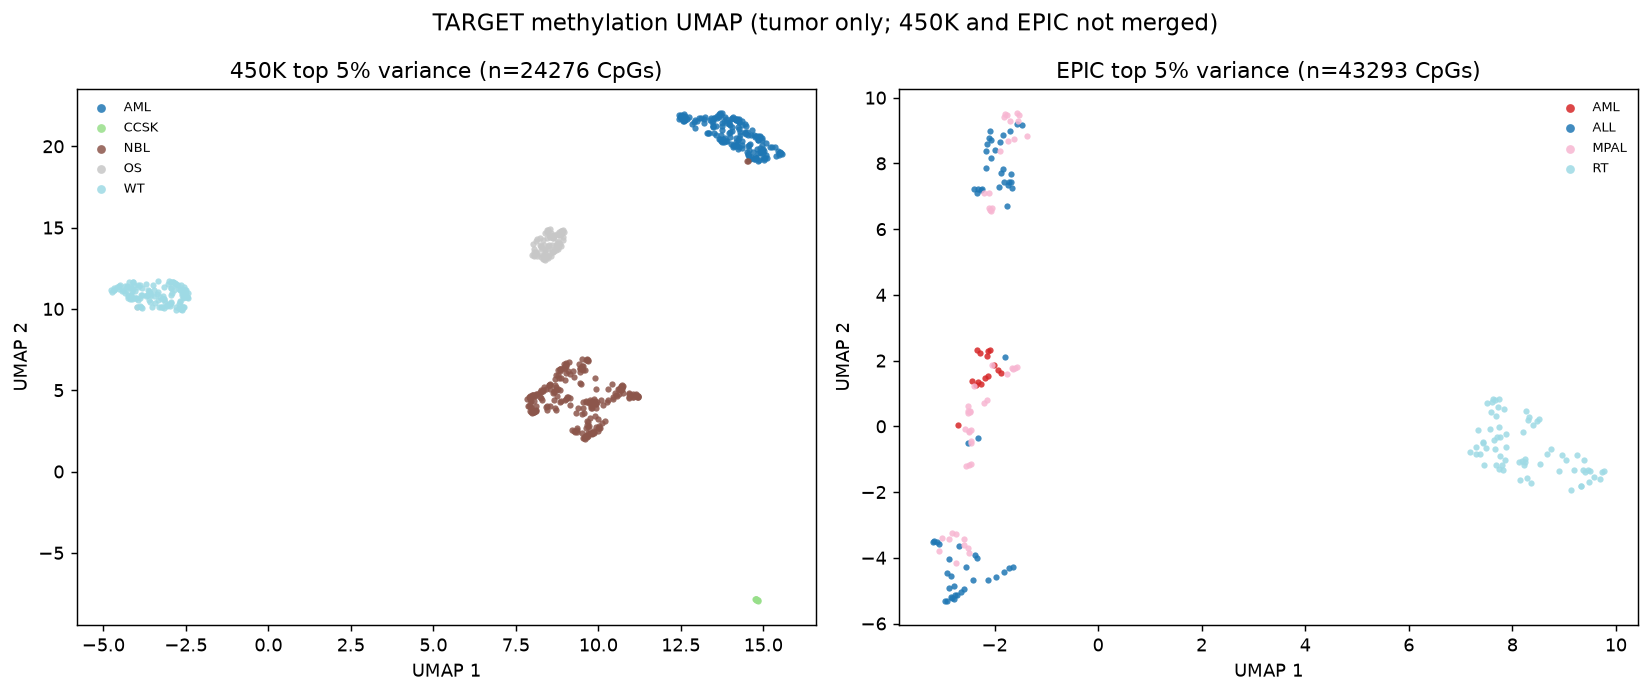

In [10]:
def tumor_only_copies(files, inventory):
    keep = set(inventory.loc[~inventory.is_normal, "sample_id"])
    copies = []
    for f in files:
        pairs = [(s, c) for s, c in zip(f["sample_ids"], f["beta_cols"]) if s in keep]
        if not pairs:
            continue
        g = dict(f)
        g["sample_ids"] = [s for s, _ in pairs]
        g["beta_cols"] = [c for _, c in pairs]
        g["n_samples"] = len(pairs)
        copies.append(g)
    return copies


print("files on disk:")
print(
    meth_inventory.groupby(["platform", "source_file"])
    .agg(arrays=("sample_id", "size"), normal=("is_normal", "sum"))
    .to_string()
)
print(
    f"\nDropping {int(meth_inventory.is_normal.sum()):,} normal/remission arrays "
    "before variance + UMAP"
)

meth_umap_tables = {}
for platform in ("450K", "EPIC"):
    files = tumor_only_copies(
        [f for f in meth_files if f["platform"] == platform],
        meth_inventory,
    )
    if not files:
        continue
    print(f"\n{platform} tumor files: " + ", ".join(f"{f['path'].name} ({f['n_samples']})" for f in files))
    top5, _stats = stream_beta_variance(files)
    top5.to_csv(METH_OUT / f"{platform}_top5pct_cpgs.tsv", sep="\t", index=False)
    beta = load_selected_beta(files, top5.cpg_id.tolist())
    keep_ids = [sid for f in files for sid in f["sample_ids"]]
    meta = (
        meth_inventory[meth_inventory.sample_id.isin(keep_ids)]
        .set_index("sample_id")
        .loc[keep_ids]
        .reset_index()
    )
    if beta.shape[1] != len(meta):
        raise ValueError(f"{platform}: {beta.shape[1]} arrays vs {len(meta)} manifest rows")
    xy = fit_umap(beta)
    table = meta.copy()
    table["UMAP1"] = xy[:, 0]
    table["UMAP2"] = xy[:, 1]
    table.to_csv(METH_OUT / f"{platform}_top5pct_umap.tsv", sep="\t", index=False)
    meth_umap_tables[platform] = (xy, table, len(top5))

fig, axes = plt.subplots(1, len(meth_umap_tables), figsize=(6.4 * len(meth_umap_tables), 5.4))
if len(meth_umap_tables) == 1:
    axes = [axes]
for ax, platform in zip(axes, meth_umap_tables):
    xy, table, n5 = meth_umap_tables[platform]
    scatter_by_label(
        ax, xy, table.disease,
        f"{platform} top 5% variance (n={n5} CpGs)",
    )
fig.suptitle("TARGET methylation UMAP (tumor only; 450K and EPIC not merged)", fontsize=13)
fig.tight_layout()
fig.savefig(METH_OUT / "methylation_top5_by_barcode_disease.png", dpi=300, bbox_inches="tight")
plt.show()

### DNA methylation — common 450K ∩ EPIC CpGs

Platform-specific UMAPs stay above. Here we keep **tumor arrays from both platforms**, take CpGs present in every 450K and EPIC file, rank by variance on the pooled samples, and embed **one** UMAP.

Saves under `outputs/data_processing/methyl/common_450k_epic/`:
- `common_eligible_cpgs.tsv` — intersection after coverage filter
- `common_top5pct_cpgs.tsv` — top 5% of those, used for UMAP
- `umap_labeled.tsv` — sample metadata + diagnosis + UMAP
- `umap_unlabeled.tsv` — sample_id, platform, UMAP only (no diagnosis)


tumor arrays: 450K=628  EPIC=192  pooled=820
450K∩EPIC: 452,453 shared CpGs across 7 files
  scanning idat_sample_sheet_TARGET-AML__450k_beta.txt (177 arrays)
  scanning idat_sample_sheet_TARGET-CCSK__450k_beta.txt (11 arrays)
  scanning idat_sample_sheet_TARGET-NBL__450k_beta.txt (223 arrays)
  scanning idat_sample_sheet_TARGET-OS__450k_beta.txt (86 arrays)
  scanning idat_sample_sheet_TARGET-WT__450k_beta.txt (131 arrays)
  scanning idat_sample_sheet_TARGET-ALL-P3__EPIC_beta.txt (124 arrays)
  scanning idat_sample_sheet_TARGET-RT__EPIC_beta.txt (68 arrays)
450K∩EPIC: 820 arrays; eligible 452,453; top 5% = 22,623
common eligible CpGs (in all files, coverage ≥ 95%): 452,453
top 5% of common eligible: 22,623
UMAP input: 820 samples x 22623 features


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


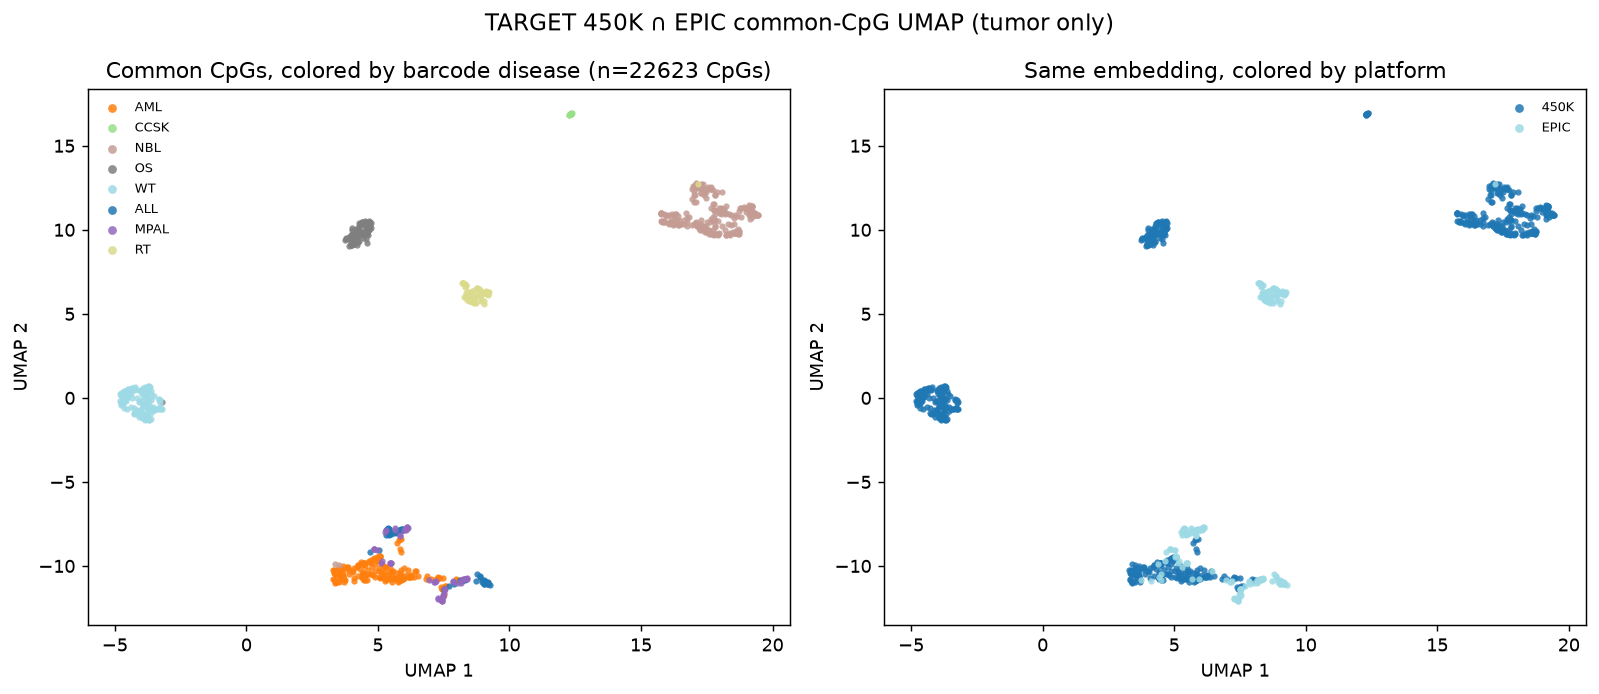

saved /Users/rita/medgemma-fl/outputs/data_processing/methyl/common_450k_epic
disease   ALL  AML  CCSK  MPAL  NBL  OS  RT   WT
platform                                        
450K        0  177    11     0  223  86   0  131
EPIC       59   15     0    50    0   0  68    0


In [11]:
COMMON_OUT = METH_OUT / "common_450k_epic"
COMMON_OUT.mkdir(parents=True, exist_ok=True)

files_450k = tumor_only_copies(
    [f for f in meth_files if f["platform"] == "450K"], meth_inventory,
)
files_epic = tumor_only_copies(
    [f for f in meth_files if f["platform"] == "EPIC"], meth_inventory,
)
common_files = files_450k + files_epic
if not files_450k or not files_epic:
    raise ValueError("Need tumor arrays on both 450K and EPIC to take a CpG intersection")

print(
    f"tumor arrays: 450K={sum(f['n_samples'] for f in files_450k):,}  "
    f"EPIC={sum(f['n_samples'] for f in files_epic):,}  "
    f"pooled={sum(f['n_samples'] for f in common_files):,}"
)

common_top5, common_stats = stream_beta_variance(common_files, label="450K∩EPIC")
min_obs = max(4, math.ceil(sum(f["n_samples"] for f in common_files) * METH_MIN_PROBE_COVERAGE))
common_eligible = common_stats.loc[
    (common_stats.n_observed >= min_obs) & (common_stats.beta_variance > 1e-10)
].sort_values("beta_variance", ascending=False)
print(f"common eligible CpGs (in all files, coverage ≥ {METH_MIN_PROBE_COVERAGE:.0%}): {len(common_eligible):,}")
print(f"top 5% of common eligible: {len(common_top5):,}")

common_eligible.to_csv(COMMON_OUT / "common_eligible_cpgs.tsv", sep="\t", index=False)
common_top5.to_csv(COMMON_OUT / "common_top5pct_cpgs.tsv", sep="\t", index=False)

common_beta = load_selected_beta(common_files, common_top5.cpg_id.tolist())
common_ids = [sid for f in common_files for sid in f["sample_ids"]]
common_meta = (
    meth_inventory[meth_inventory.sample_id.isin(common_ids)]
    .set_index("sample_id")
    .loc[common_ids]
    .reset_index()
)
if common_beta.shape[1] != len(common_meta):
    raise ValueError(f"common: {common_beta.shape[1]} arrays vs {len(common_meta)} manifest rows")

common_xy = fit_umap(common_beta)

labeled = common_meta.copy()
labeled["UMAP1"] = common_xy[:, 0]
labeled["UMAP2"] = common_xy[:, 1]
unlabeled = labeled[["sample_id", "platform", "UMAP1", "UMAP2"]].copy()

labeled.to_csv(COMMON_OUT / "umap_labeled.tsv", sep="\t", index=False)
unlabeled.to_csv(COMMON_OUT / "umap_unlabeled.tsv", sep="\t", index=False)
np.savez_compressed(
    COMMON_OUT / "common_top5pct_beta.npz",
    beta=common_beta,
    cpg_id=common_top5.cpg_id.to_numpy(),
    sample_id=np.asarray(common_ids),
)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.4))
scatter_by_label(
    axes[0], common_xy, labeled.disease,
    f"Common CpGs, colored by barcode disease (n={len(common_top5)} CpGs)",
)
scatter_by_label(
    axes[1], common_xy, labeled.platform,
    "Same embedding, colored by platform",
)
fig.suptitle("TARGET 450K ∩ EPIC common-CpG UMAP (tumor only)", fontsize=13)
fig.tight_layout()
fig.savefig(COMMON_OUT / "common_450k_epic_umap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {COMMON_OUT}")
print(labeled.groupby(["platform", "disease"]).size().unstack(fill_value=0).to_string())


### PCGP


PCGP count files: ['WU-Harmonization-PCGP-UNSTRANDED_RSEM_gene_count.2022-04-17_13-05-36.txt']
PCGP samples: 933  (no diagnosis metadata used)
eligible 18,776; top 5% 939; TMM median 1.065
UMAP input: 933 samples x 939 features


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


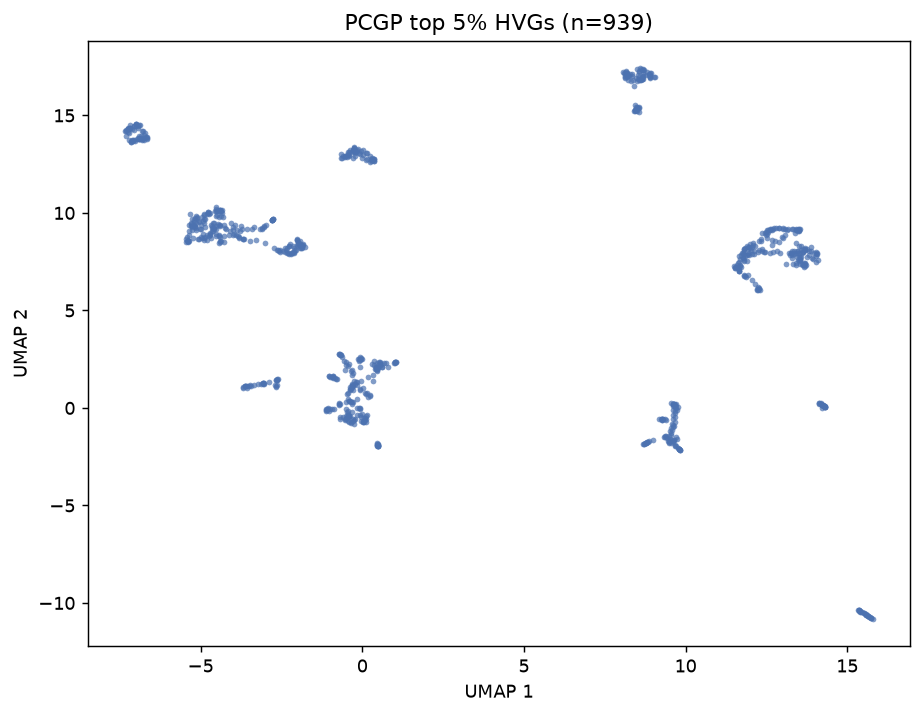

saved /Users/rita/medgemma-fl/outputs/data_processing/pcgp  (933 samples, 939 HVGs)


In [12]:
pcgp_files = sorted(
    p for p in PCGP_DIR.glob("*.txt")
    if "RSEM_GENE_COUNT" in p.name.upper() and "TPM" not in p.name.upper()
)
print("PCGP count files:", [p.name for p in pcgp_files])
if len(pcgp_files) != 1:
    raise ValueError("Expected one PCGP gene_count file")

g_ids, g_sym, g_bio, sids, pcgp_counts = read_count_table(pcgp_files[0])
if len(sids) != len(set(sids)):
    raise ValueError("Duplicate PCGP sample IDs")

pcgp_meta = pd.DataFrame({"sample_id": sids})
print(f"PCGP samples: {len(pcgp_meta):,}  (no diagnosis metadata used)")

pcgp_eligible = protein_coding_expressed(pcgp_counts, g_bio)
pcgp_log, pcgp_tmm = log2_tmm_cpm(pcgp_counts)
pcgp_top5_idx, _ = top_variance_indices(pcgp_log, 0.05, pcgp_eligible)
print(
    f"eligible {int(pcgp_eligible.sum()):,}; top 5% {len(pcgp_top5_idx)}; "
    f"TMM median {np.median(pcgp_tmm):.3f}"
)

pcgp_xy = fit_umap(pcgp_log[pcgp_top5_idx])
pcgp_coords = pcgp_meta.copy()
pcgp_coords["UMAP1"] = pcgp_xy[:, 0]
pcgp_coords["UMAP2"] = pcgp_xy[:, 1]
pcgp_coords.to_csv(PCGP_OUT / "pcgp_top5pct_umap.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(7.2, 5.6))
ax.scatter(pcgp_xy[:, 0], pcgp_xy[:, 1], s=10, c="#4C72B0", alpha=0.7, linewidths=0)
ax.set(
    title=f"PCGP top 5% HVGs (n={len(pcgp_top5_idx)})",
    xlabel="UMAP 1",
    ylabel="UMAP 2",
)
fig.tight_layout()
fig.savefig(PCGP_OUT / "pcgp_top5_unlabeled.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {PCGP_OUT}  ({len(pcgp_meta):,} samples, {len(pcgp_top5_idx)} HVGs)")

### COMET RMS methylation

COMET EPIC arrays for **rhabdomyosarcoma only**. 547 arrays, all labeled RMS.

UMAP here can show sample type (patient tumor / PDX / cell line), not disease class.


Sample.Type
Patient tumor    477
Xenograft         47
Cell line         23
COMET RMS: 547 Ave_Beta arrays (Detection.Pval columns ignored); id column = 'TargetID'
meta match: sample_type
Patient tumor    477
Xenograft         47
Cell line         23
EPIC: 865,859 shared CpGs across 1 files
  scanning RMSs_beta.txt (547 arrays)
EPIC: 547 arrays; eligible 865,859; top 5% = 43,293
UMAP input: 547 samples x 43293 features


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


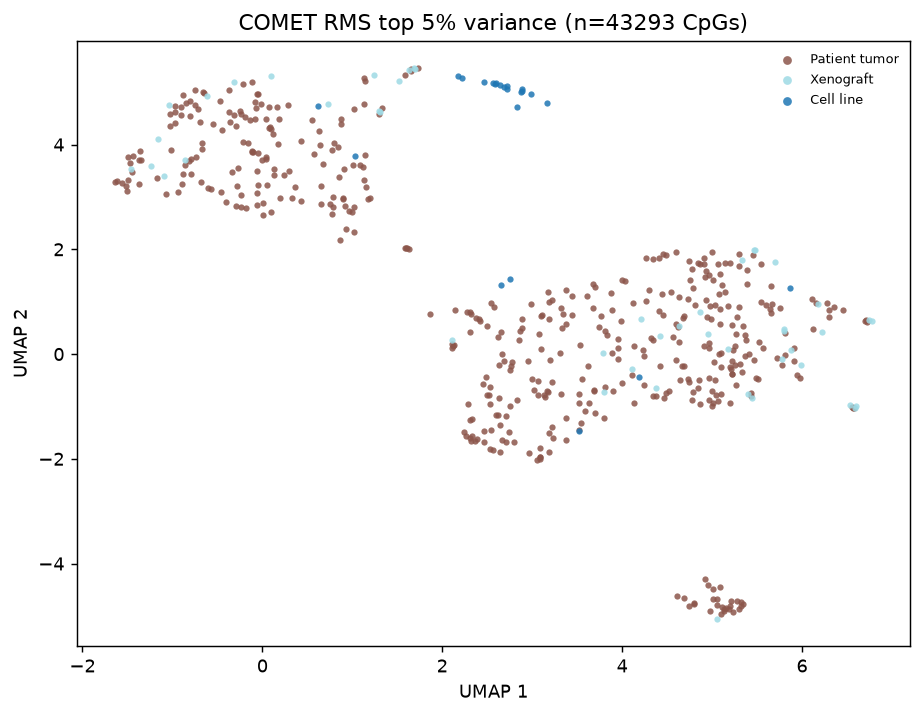

saved /Users/rita/medgemma-fl/outputs/data_processing/comet_rms  (547 arrays, 43293 CpGs)


In [13]:
comet_beta_path = COMET_DIR / "RMSs_beta.txt"
comet_meta_path = COMET_DIR / "RMSs_meta.txt"
comet_meta = pd.read_csv(comet_meta_path, sep="\t")
print(comet_meta["Sample.Type"].value_counts().to_string())

comet_info = {
    "path": comet_beta_path,
    "platform": "EPIC",
    "file_project": "COMET-RMS",
    "beta_cols": None,
    "sample_ids": None,
    "n_samples": None,
}
with open(comet_beta_path, encoding="utf-8-sig") as handle:
    header = handle.readline().rstrip("\n").split("\t")
comet_info["id_col"] = header[0]
comet_info["beta_cols"] = [c for c in header[1:] if c.endswith(".Ave_Beta")]
comet_info["sample_ids"] = [c[: -len(".Ave_Beta")] for c in comet_info["beta_cols"]]
comet_info["n_samples"] = len(comet_info["beta_cols"])
print(
    f"COMET RMS: {comet_info['n_samples']:,} Ave_Beta arrays "
    f"(Detection.Pval columns ignored); id column = {comet_info['id_col']!r}"
)

meta_by_name = comet_meta.set_index("Sample_Name")
comet_labels = []
for sid in comet_info["sample_ids"]:
    if sid not in meta_by_name.index:
        comet_labels.append({"sample_id": sid, "sample_type": "UNKNOWN", "sjid": None})
        continue
    row = meta_by_name.loc[sid]
    comet_labels.append({
        "sample_id": sid,
        "sample_type": row["Sample.Type"],
        "sjid": row["SJID"],
        "subject": row["UID.Subject"],
        "source": row["Source"],
    })
comet_table = pd.DataFrame(comet_labels)
print("meta match:", comet_table.sample_type.value_counts().to_string())

comet_top5, _ = stream_beta_variance([comet_info])
comet_top5.to_csv(COMET_OUT / "comet_rms_top5pct_cpgs.tsv", sep="\t", index=False)
comet_beta = load_selected_beta([comet_info], comet_top5.cpg_id.tolist())
comet_xy = fit_umap(comet_beta)
comet_table["UMAP1"] = comet_xy[:, 0]
comet_table["UMAP2"] = comet_xy[:, 1]
comet_table.to_csv(COMET_OUT / "comet_rms_top5pct_umap.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(7.2, 5.6))
scatter_by_label(
    ax,
    comet_xy,
    comet_table.sample_type,
    f"COMET RMS top 5% variance (n={len(comet_top5)} CpGs)",
)
fig.tight_layout()
fig.savefig(COMET_OUT / "comet_rms_top5_by_sample_type.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {COMET_OUT}  ({len(comet_table):,} arrays, {len(comet_top5)} CpGs)")


### COMET RMS — patient tumor only

Xenografts and cell lines stay in the plot above. Here keep only `Sample.Type == "Patient tumor"` (477 arrays), re-rank top 5% variance, and draw an unlabeled UMAP.


Dropping 70 xenograft/cell-line arrays before variance + UMAP
patient tumor arrays: 477
COMET patient tumor: 865,859 shared CpGs across 1 files
  scanning RMSs_beta.txt (477 arrays)
COMET patient tumor: 477 arrays; eligible 865,859; top 5% = 43,293
UMAP input: 477 samples x 43293 features


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


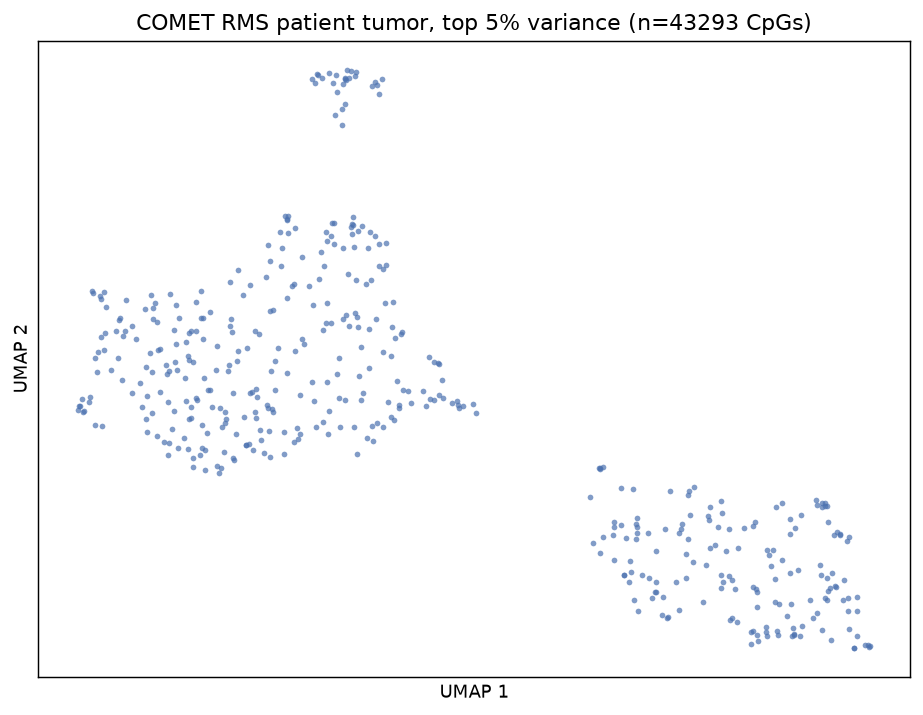

saved /Users/rita/medgemma-fl/outputs/data_processing/comet_rms/patient_tumor  (477 patient tumors, 43293 CpGs)


In [14]:
COMET_TUMOR_OUT = COMET_OUT / "patient_tumor"
COMET_TUMOR_OUT.mkdir(parents=True, exist_ok=True)

keep_ids = comet_table.loc[comet_table.sample_type.eq("Patient tumor"), "sample_id"]
keep = set(keep_ids)
n_drop = int((~comet_table.sample_type.eq("Patient tumor")).sum())

comet_tumor_info = {
    "path": comet_info["path"],
    "platform": comet_info["platform"],
    "file_project": comet_info["file_project"],
    "id_col": comet_info["id_col"],
}
pairs = [
    (sid, col)
    for sid, col in zip(comet_info["sample_ids"], comet_info["beta_cols"])
    if sid in keep
]
comet_tumor_info["sample_ids"] = [sid for sid, _ in pairs]
comet_tumor_info["beta_cols"] = [col for _, col in pairs]
comet_tumor_info["n_samples"] = len(pairs)
comet_tumor_table = (
    comet_table.set_index("sample_id")
    .loc[comet_tumor_info["sample_ids"]]
    .reset_index()
)

print(f"Dropping {n_drop} xenograft/cell-line arrays before variance + UMAP")
print(f"patient tumor arrays: {comet_tumor_info['n_samples']}")

comet_tumor_top5, _ = stream_beta_variance([comet_tumor_info], label="COMET patient tumor")
comet_tumor_top5.to_csv(COMET_TUMOR_OUT / "comet_rms_patient_tumor_top5pct_cpgs.tsv", sep="\t", index=False)
comet_tumor_beta = load_selected_beta([comet_tumor_info], comet_tumor_top5.cpg_id.tolist())
comet_tumor_xy = fit_umap(comet_tumor_beta)
comet_tumor_table["UMAP1"] = comet_tumor_xy[:, 0]
comet_tumor_table["UMAP2"] = comet_tumor_xy[:, 1]
comet_tumor_table.to_csv(COMET_TUMOR_OUT / "comet_rms_patient_tumor_umap.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(7.2, 5.6))
ax.scatter(comet_tumor_xy[:, 0], comet_tumor_xy[:, 1], s=10, c="#4C72B0", alpha=0.7, linewidths=0)
ax.set_title(
    f"COMET RMS patient tumor, top 5% variance (n={len(comet_tumor_top5)} CpGs)"
)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
fig.savefig(COMET_TUMOR_OUT / "comet_rms_patient_tumor_umap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {COMET_TUMOR_OUT}  ({len(comet_tumor_table):,} patient tumors, {len(comet_tumor_top5)} CpGs)")
